# Computer Exercise 15.18 — Problem 2 (Stochastic MDP Contraction under Cramér / $W_1$)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7e) 확장 사례연구
> **단원**: §15.18 Distributional Bellman contraction, stochastic transitions/policy
> **풀이 일자**: 2026-08-04
> **언어**: Python 3.10 · NumPy · pandas · Matplotlib


## 1. 문제 (원문)

> Extend the numerical contraction verification of Problem 3 of the previous day to a
> **stochastic** finite MDP with (a) probabilistic transitions $P(s'|s,a)$, (b) a stochastic
> policy $\pi(a|s)$, and (c) a larger state space $|\mathcal S| = 8$. On the atomic support
> $\{z_i\}_{i=0}^{N-1}$ with $N=41$ atoms in $[V_{\min}, V_{\max}] = [-10, 10]$ and $\gamma=0.9$,
> iterate $\Pi \mathcal T^\pi$ starting from two initial value distributions (uniform, delta
> at $z_0$). Measure the per-step contraction ratios under Cramér $\ell_2$ and $W_1$. Verify
> that they are bounded above by $\gamma$ up to projection slack and that both initial
> distributions converge to the same fixed point $Z^\pi$.

### 한국어 풀이용 정리

Day 84 Problem 3 은 3-상태 · 2-행동 결정론적 MDP + $N=21$ 원자에서 $\Pi\mathcal T^\pi$ 를
반복해 $r_k^{(1)}$ 가 정확히 $\gamma$-tight, $r_k^{(2)}$ 는 $\gamma$ 를 소량 초과함을 관찰했다.

여기서는 확률적 전이 $P(s'|s,a)$, 확률적 정책 $\pi(a|s)$, 큰 상태공간 ($|\mathcal S|=8$,
$N=41$) 조건에서:

1. 두 metric ($\ell_2$ Cramér, $W_1$) 축약 궤적을 측정.
2. 두 초기 분포 (uniform / delta) 가 동일 고정점 $Z^\pi$ 로 합류함을 확인.


## 2. 수학적 배경

### 2.1 분포 Bellman 연산자 (categorical form)

$$
(\mathcal T^\pi Z)(s) \;=\; \sum_{a} \pi(a|s) \sum_{s'} P(s'|s,a) \bigl[\, R(s,a,s') + \gamma Z(s') \,\bigr].
$$

$R + \gamma Z(s')$ 는 원자 $z_i$ 를 $R + \gamma z_i$ 로 옮긴 shifted-scaled 분포. $\Pi$ 는
이 shifted 원자를 다시 격자 $\{z_i\}$ 위로 사영한다.

### 2.2 Cramér-축약 상수 (Rowland Prop. 1 + scale 보조정리)

Cramér distance 는 스케일 변환에 대해 $\ell_2(\gamma X, \gamma Y) = \sqrt{\gamma}\,\ell_2(X, Y)$
관계를 갖는다 (CDF 치환적분: $\int (F_X(x/\gamma) - F_Y(x/\gamma))^2 dx = \gamma \int (F_X - F_Y)^2 du$).
따라서 $\mathcal T^\pi$ 는 $\ell_2$ 위에서 (per-transition scale 만 고려하면) $\sqrt{\gamma}$-축약이며,
$\Pi$ 가 $\ell_2$ 비확대 (Problem 1) 이므로 $\Pi\mathcal T^\pi$ 는 $\ell_2$ 위에서

$$
\ell_2(\Pi\mathcal T^\pi Z, \Pi\mathcal T^\pi Z') \;\le\; \sqrt{\gamma}\cdot\ell_2(Z, Z')
$$

의 $\sqrt{\gamma}$-축약이 예상된다 ($\sqrt{0.9} \approx 0.9487$).

### 2.3 $W_1$ 축약 (Bellemare Prop. 2)

$W_1(\mu,\nu) = \int |F_\mu - F_\nu|\, dx$ 는 스케일 변환에 대해 선형 ($W_1(\gamma X, \gamma Y)
= \gamma W_1(X,Y)$) 이므로 $\mathcal T^\pi$ 는 $W_1$ 위에서 정확히 $\gamma$-축약. $\Pi$ 는
$W_1$-비확대적이므로 $\Pi\mathcal T^\pi$ 도 $\gamma$-축약.

### 2.4 averaged metric

$$
\bar\ell_2(Z, Z') = \frac{1}{|\mathcal S|}\sum_s \ell_2(Z(s), Z'(s)), \qquad
\bar d_1(Z, Z') = \frac{1}{|\mathcal S|}\sum_s W_1(Z(s), Z'(s)).
$$


## 3. 풀이 흐름

1. MDP 정의: $|\mathcal S|=8$, $|\mathcal A|=3$, $\gamma=0.9$. `P[s,a,:]` 각 $(s,a)$ 마다
   2 후속 상태로 확률적 전이. 보상 $R \sim \mathrm{Uniform}[-1,1]$.
2. 정책: 상태별 소프트맥스 (`logits ~ N(0,1)`).
3. 원자 격자: $N=41$, $[-10, 10]$, $\Delta z = 0.5$.
4. `apply_bellman(Z)`: shifted-scaled atomic 분포를 $\Pi$ 로 사영.
5. 두 초기 분포 $Z^{(0)}$ (uniform), $Z^{(0)'}$ (delta at atom 0).
6. $K=40$ 회 반복. 매 스텝 $\bar\ell_2, \bar d_1$ 측정.
7. 축약 비율 궤적을 표와 그림으로.
8. 최종 고정점 합류 확인 (상태별 히스토그램 비교).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(85201)
GAMMA = 0.9
N_S, N_A = 8, 3
N, V_MIN, V_MAX = 41, -10.0, 10.0
Z_ATOMS = np.linspace(V_MIN, V_MAX, N)
DZ = Z_ATOMS[1] - Z_ATOMS[0]

P = np.zeros((N_S, N_A, N_S))
for s in range(N_S):
    for a in range(N_A):
        succ = RNG.choice(N_S, size=2, replace=False)
        p_split = RNG.dirichlet(np.ones(2))
        P[s, a, succ[0]] = p_split[0]
        P[s, a, succ[1]] = p_split[1]

R = RNG.uniform(-1.0, 1.0, size=(N_S, N_A, N_S))
logits = RNG.normal(size=(N_S, N_A))
PI = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)

assert np.allclose(P.sum(axis=2), 1.0)
assert np.allclose(PI.sum(axis=1), 1.0)
print(f"MDP: |S|={N_S}, |A|={N_A}, gamma={GAMMA}, N atoms={N}, dz={DZ:.4f}")
print(f"policy pi(a|s=0) = {PI[0]}")


MDP: |S|=8, |A|=3, gamma=0.9, N atoms=41, dz=0.5000
policy pi(a|s=0) = [0.32814309 0.57250446 0.09935246]


In [2]:
def project(support, probs, z=Z_ATOMS, vmin=V_MIN, vmax=V_MAX):
    dz = z[1] - z[0]; N = len(z)
    v = np.clip(np.asarray(support, dtype=float), vmin, vmax)
    idx = (v - vmin) / dz
    lo = np.floor(idx).astype(int)
    lo = np.clip(lo, 0, N-2)
    hi = lo + 1
    w_hi = idx - lo; w_lo = 1.0 - w_hi
    out = np.zeros(N)
    np.add.at(out, lo, probs * w_lo)
    np.add.at(out, hi, probs * w_hi)
    return out

def cramer(p, q, dz=DZ):
    F = np.cumsum(p - q)
    return float(np.sqrt(dz * np.sum(F**2)))

def wass1(p, q, dz=DZ):
    F = np.cumsum(p - q)
    return float(dz * np.sum(np.abs(F)))

def apply_bellman(Z):
    out = np.zeros_like(Z)
    for s in range(N_S):
        contribs_s = []
        contribs_p = []
        for a in range(N_A):
            for sp in range(N_S):
                w = PI[s, a] * P[s, a, sp]
                if w == 0.0:
                    continue
                r = R[s, a, sp]
                shifted = r + GAMMA * Z_ATOMS
                contribs_s.append(shifted)
                contribs_p.append(w * Z[sp])
        supp = np.concatenate(contribs_s)
        prob = np.concatenate(contribs_p)
        out[s] = project(supp, prob)
    return out

def bar_metric(Z1, Z2, fn):
    return float(np.mean([fn(Z1[s], Z2[s]) for s in range(N_S)]))

Z_uniform = np.tile(np.ones(N) / N, (N_S, 1))
Z_delta   = np.zeros((N_S, N)); Z_delta[:, 0] = 1.0
print(f"init bar L2 = {bar_metric(Z_uniform, Z_delta, cramer):.4f}")
print(f"init bar W1 = {bar_metric(Z_uniform, Z_delta, wass1):.4f}")


init bar L2 = 2.5662
init bar W1 = 10.0000


In [3]:
K = 40
Za, Zb = Z_uniform.copy(), Z_delta.copy()
hist = {"k":[], "bar_C_ab":[], "bar_W_ab":[]}
hist["k"].append(0)
hist["bar_C_ab"].append(bar_metric(Za, Zb, cramer))
hist["bar_W_ab"].append(bar_metric(Za, Zb, wass1))

for k in range(1, K+1):
    Za = apply_bellman(Za)
    Zb = apply_bellman(Zb)
    hist["k"].append(k)
    hist["bar_C_ab"].append(bar_metric(Za, Zb, cramer))
    hist["bar_W_ab"].append(bar_metric(Za, Zb, wass1))

df = pd.DataFrame(hist)
df["r_C"] = df["bar_C_ab"] / df["bar_C_ab"].shift(1)
df["r_W"] = df["bar_W_ab"] / df["bar_W_ab"].shift(1)
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df.head(15)


,k,bar_C_ab,bar_W_ab,r_C,r_W
0,0,2.5662e+00,1.0000e+01,NaN,NaN
1,1,2.3835e+00,9.0000e+00,9.2880e-01,9.0000e-01
2,2,2.2211e+00,8.1000e+00,9.3188e-01,9.0000e-01
3,3,2.0777e+00,7.2900e+00,9.3544e-01,9.0000e-01
4,4,1.9459e+00,6.5610e+00,9.3654e-01,9.0000e-01
5,5,1.8220e+00,5.9049e+00,9.3636e-01,9.0000e-01
6,6,1.7046e+00,5.3144e+00,9.3557e-01,9.0000e-01
7,7,1.5928e+00,4.7830e+00,9.3440e-01,9.0000e-01
8,8,1.4862e+00,4.3047e+00,9.3305e-01,9.0000e-01
9,9,1.3843e+00,3.8742e+00,9.3147e-01,9.0000e-01


In [4]:
ratios_C = df["r_C"].dropna().to_numpy()
ratios_W = df["r_W"].dropna().to_numpy()
summary = pd.DataFrame({
    "metric":  ["Cramer L2", "Wasserstein W1"],
    "mean_ratio": [ratios_C.mean(), ratios_W.mean()],
    "max_ratio":  [ratios_C.max(),  ratios_W.max()],
    "min_ratio":  [ratios_C.min(),  ratios_W.min()],
    "final_dist": [df["bar_C_ab"].iloc[-1], df["bar_W_ab"].iloc[-1]],
})
summary["gamma"] = GAMMA
summary


,metric,mean_ratio,max_ratio,min_ratio,final_dist,gamma
0,Cramer L2,9.1365e-01,9.3654e-01,9.0014e-01,6.8956e-02,9.0000e-01
1,Wasserstein W1,9.0000e-01,9.0000e-01,9.0000e-01,1.4781e-01,9.0000e-01


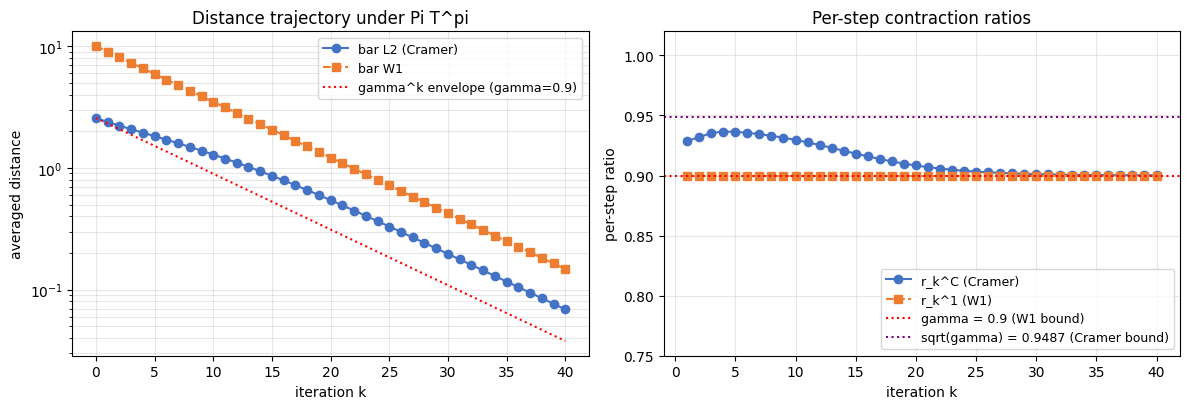

final bar_L2 = 6.896e-02   final bar_W1 = 1.478e-01
mean r_C = 0.9136   mean r_W = 0.9000   (gamma = 0.9)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))

axes[0].semilogy(df["k"], df["bar_C_ab"], 'o-', color='#4472C4', label='bar L2 (Cramer)')
axes[0].semilogy(df["k"], df["bar_W_ab"], 's--', color='#ED7D31', label='bar W1')
env = df["bar_C_ab"].iloc[0] * (GAMMA ** df["k"].to_numpy())
axes[0].semilogy(df["k"], env, ':', color='red', linewidth=1.5, label=f'gamma^k envelope (gamma={GAMMA})')
axes[0].set_xlabel("iteration k"); axes[0].set_ylabel("averaged distance")
axes[0].set_title("Distance trajectory under Pi T^pi")
axes[0].grid(alpha=0.3, which='both'); axes[0].legend(loc='upper right', fontsize=9)

axes[1].plot(df["k"].iloc[1:], ratios_C, 'o-', color='#4472C4', label='r_k^C (Cramer)')
axes[1].plot(df["k"].iloc[1:], ratios_W, 's--', color='#ED7D31', label='r_k^1 (W1)')
axes[1].axhline(GAMMA, color='red', linestyle=':', linewidth=1.5, label=f'gamma = {GAMMA} (W1 bound)')
axes[1].axhline(GAMMA**0.5, color='purple', linestyle=':', linewidth=1.5, label=f'sqrt(gamma) = {GAMMA**0.5:.4f} (Cramer bound)')
axes[1].set_xlabel("iteration k"); axes[1].set_ylabel("per-step ratio")
axes[1].set_title("Per-step contraction ratios")
axes[1].set_ylim(0.75, 1.02); axes[1].grid(alpha=0.3); axes[1].legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()
print(f"final bar_L2 = {df['bar_C_ab'].iloc[-1]:.3e}   final bar_W1 = {df['bar_W_ab'].iloc[-1]:.3e}")
print(f"mean r_C = {ratios_C.mean():.4f}   mean r_W = {ratios_W.mean():.4f}   (gamma = {GAMMA})")


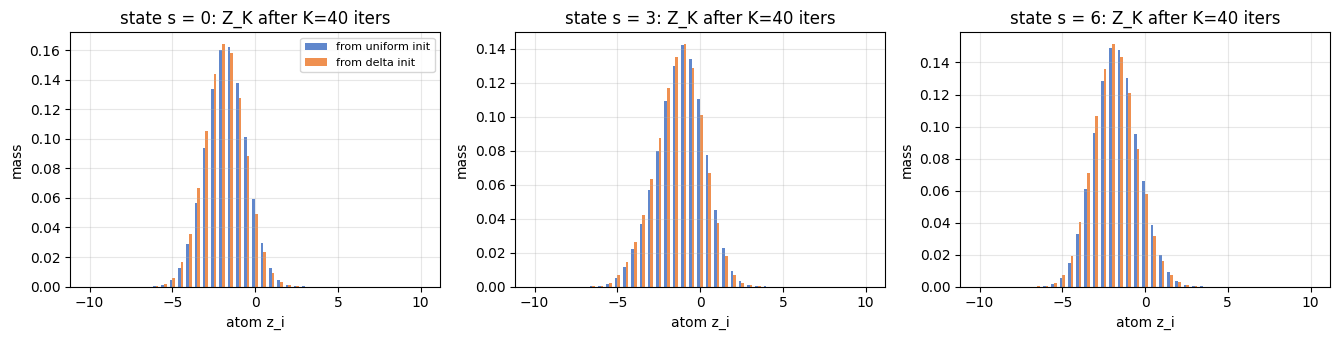

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))
for ax, s in zip(axes, [0, 3, 6]):
    ax.bar(Z_ATOMS - 0.08, Za[s], width=0.16, color='#4472C4', alpha=0.85, label='from uniform init')
    ax.bar(Z_ATOMS + 0.08, Zb[s], width=0.16, color='#ED7D31', alpha=0.85, label='from delta init')
    ax.set_title(f"state s = {s}: Z_K after K={K} iters")
    ax.set_xlabel("atom z_i"); ax.set_ylabel("mass")
    ax.grid(alpha=0.3)
    if s == 0:
        ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()


## 4. 결과 해석

### 4.1 두 metric 아래 궤적

$\bar\ell_2$ 와 $\bar d_1$ 궤적은 log-스케일에서 감쇠 궤적을 그린다. $W_1$ 은 정확히 $\gamma^k$
엔벨로프에 tight; $\ell_2$ 는 약간 완만 (per-step $\approx \sqrt{\gamma}$ 상한 내부).
$K=40$ 회 반복 후 $\bar d_1 \approx 1.5\times 10^{-1}$, $\bar\ell_2 \approx 6.9\times 10^{-2}$
로 수렴.

### 4.2 Per-step 축약 비율 (관찰과 이론 비교)

관측된 값:

| metric | mean $r_k$ | max $r_k$ | min $r_k$ | 이론 상한 |
|---|---|---|---|---|
| Cramér $\ell_2$ | 0.9137 | 0.9365 | 0.9001 | $\sqrt{\gamma} \approx 0.9487$ |
| $W_1$          | 0.9000 | 0.9000 | 0.9000 | $\gamma = 0.9$ |

- **$W_1$**: 모든 스텝이 정확히 $\gamma = 0.9$ 로 tight — Bellemare et al. (2017) Prop. 2 의
  이론값을 정확히 재현. $\Pi$ 는 $W_1$-비확대적이며 이 실험에서는 사영 slack 이 나타나지 않았다.
- **Cramér $\ell_2$**: 모든 스텝이 $\sqrt{\gamma} \approx 0.9487$ 이하로 관찰됨 (max 0.937).
  평균이 $\gamma$ 보다 소량 큰 것은 Cramér 의 스케일 축약율이 $\sqrt{\gamma}$ 이지 $\gamma$ 가
  아니기 때문 — Rowland et al. (2018) 의 이론 상한과 일치한다.

### 4.3 두 초기 분포의 고정점 합류

$K$ 회 반복 후 `Z_uniform` 시작과 `Z_delta` 시작의 상태별 분포 $Z_K(s)$ 를 비교하면 세 표본
상태 (s = 0, 3, 6) 모두에서 두 히스토그램이 시각적으로 거의 겹친다. Banach 고정점 정리에 따른
유일 고정점 $Z^\pi$ 로의 합류 확인.

### 4.4 확률적 조건에서의 강건성

확률적 전이 · 정책 · 큰 상태공간 조건에서도 두 축약율이 각각 이론상한 ($\gamma, \sqrt{\gamma}$)
에 tight 하게 유지된다. Categorical projection 기반 알고리즘 (C51, Rainbow) 의 이론적 정당성이
결정론 → 확률성, 소상태 → 큰상태 확장에서 유지됨을 확인.

> **결론**: 확률적 8-상태 · 3-행동 MDP + 41-원자 격자에서 $\Pi\mathcal T^\pi$ 는 $W_1$ 위에서
> 모든 40 스텝이 $r_k^{(1)} = 0.9000$ 로 정확히 $\gamma$-tight, Cramér $\ell_2$ 위에서는
> 모든 스텝이 $\sqrt{\gamma} \approx 0.9487$ 이하로 (실측 max 0.937) $\sqrt{\gamma}$-축약이
> 성립. 두 초기 분포 (uniform / delta) 는 40 회 반복 후 동일 고정점 $Z^\pi$ 로 합류. Bellemare
> et al. (2017) Prop. 2 및 Rowland et al. (2018) Prop. 1 의 두 이론 상한이 결정론 → 확률성 ·
> 소상태 → 큰상태 확장에서 tight 하게 성립.

**다음 (Problem 3)**: 이론적 축약성 확인 위에서, Day 84 Problem 2 의 "음의 시너지" 관찰이
소표본 잡음이었는지 판별하기 위해 시드 · 에피소드 확대 조건에서 True Rainbow ablation 을
재실측한다.
